[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\milan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


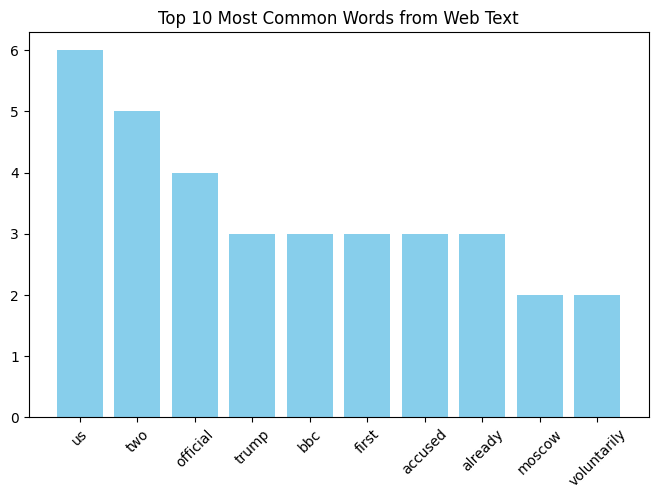

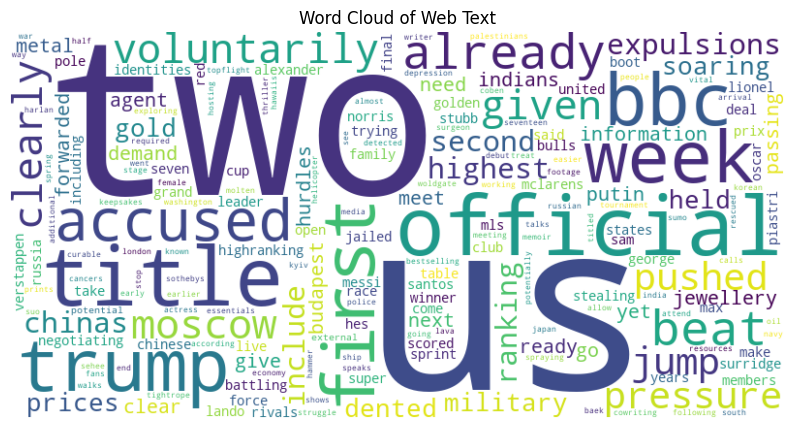

In [1]:
# !pip install wordcloud beautifulsoup4 requests nltk

import requests
from bs4 import BeautifulSoup
import re
from collections import Counter
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download("stopwords")
from nltk.corpus import stopwords

# 1. Collect Web Text Data
url = "https://www.bbc.com/news"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

text_data = " ".join([p.get_text() for p in soup.find_all("p")])

# 2. Preprocess Text
text_data = text_data.lower()
text_data = re.sub(r"[^a-z\s]", "", text_data)
words = text_data.split()

stop_words = set(stopwords.words("english"))
filtered_words = [w for w in words if w not in stop_words]

# 3. Visualization

# (a) Word Frequency - Bar Plot
word_counts = Counter(filtered_words)
common_words = word_counts.most_common(10)

words_, counts_ = zip(*common_words)
plt.figure(figsize=(8,5))
plt.bar(words_, counts_, color="skyblue")
plt.title("Top 10 Most Common Words from Web Text")
plt.xticks(rotation=45)
plt.show()

# (b) Word Cloud
wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(filtered_words))
plt.figure(figsize=(10,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Web Text")
plt.show()